# Control vision project


# Setting up the working environment
Installation of dependencies, necessary tools, and the database

In [ ]:
import os
import pandas as pd
import ast
import shutil
from google.colab import drive
from PIL import Image
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import yaml
from google.colab import files
import matplotlib.pyplot as plt
from tqdm import tqdm


### Environment Initialization and Data Download

This section configures the necessary dependencies, downloads the CADDY dataset from Kaggle, and decompresses it to make it usable in the Colab environment. It also ensures that the environment is clean of any previous folders to avoid conflicts.

In [ ]:
from google.colab import userdata
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
!pip install kaggle -q
!kaggle datasets download -d ssahu912/underwater-caddy-gestures

Dataset URL: https://www.kaggle.com/datasets/ssahu912/underwater-caddy-gestures
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.50G/2.50G [00:28<00:00, 94.1MB/s]



In [ ]:
!unzip underwater-caddy-gestures.zip -d /content/caddy_dataset

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/caddy_dataset/CADDY_gestures_complete_v2_release/genova-A/true_positives/raw/genova-A_00820_left.jpg  
  inflating: /content/caddy_dataset/CADDY_gestures_complete_v2_release/genova-A/true_positives/raw/genova-A_00820_right.jpg  
  inflating: /content/caddy_dataset/CADDY_gestures_complete_v2_release/genova-A/true_positives/raw/genova-A_00821_left.jpg  
  inflating: /content/caddy_dataset/CADDY_gestures_complete_v2_release/genova-A/true_positives/raw/genova-A_00821_right.jpg  
  inflating: /content/caddy_dataset/CADDY_gestures_complete_v2_release/genova-A/true_positives/raw/genova-A_00822_left.jpg  
  inflating: /content/caddy_dataset/CADDY_gestures_complete_v2_release/genova-A/true_positives/raw/genova-A_00822_right.jpg  
  inflating: /content/caddy_dataset/CADDY_gestures_complete_v2_release/genova-A/true_positives/raw/genova-A_00823_left.jpg  
  inflating: /content/caddy_dataset/CADDY_ge

### Cleaning the Working Environment

This `clean_environment` function deletes temporary folders and zip files from previous runs, ensuring a clean start for data processing or model training. It is called at the beginning to avoid interference.

Environment cleaning

In [ ]:
drive.mount('/content/drive')

def clean_environment():
    print("--- 🧹 Cleaning the environment ---")
    folders_to_delete = [
        '/content/caddy_dataset/dataset_sample_416',
        '/content/yolo_dataset'
    ]

    for folder in folders_to_delete:
        if os.path.exists(folder):
            shutil.rmtree(folder)
            print(f"🗑️ Old folder deleted: {folder}")

    if os.path.exists('/content/yolo_dataset_backup.zip'):
        os.remove('/content/yolo_dataset_backup.zip')

    print("✨ Environment is clean.")

clean_environment()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- 🧹 Cleaning the environment ---
🗑️ Old folder deleted: /content/yolo_dataset
✨ Environment is clean.


# Data preprocessing
[Importing a new dataset for training](https://docs.ultralytics.com/fr/datasets/#contribute-new-datasets)

## Loading and Initial CSV Data Filtering

We start by loading the main CSV file containing the gesture annotations. We then filter the columns to keep only the strictly necessary ones, such as the image path, label name and ID, and the region of interest (ROI) coordinates for the left camera. A preview is displayed to verify the coordinate format.

In [ ]:
csv_file = '/content/caddy_dataset/CADDY_gestures_complete_v2_release/CADDY_gestures_all_true_positives_release_v2.csv'
df_positives = pd.read_csv(csv_file)

# Keep only the strictly useful columns
useful_columns = ['stereo left', 'label name', 'label id', 'roi left']
df_filtered = df_positives[useful_columns].copy()

# Display total number of images
total_images = len(df_filtered)
print(f"Total number of images (left camera): {total_images}")

# Check hand coordinate format
print("\n--- Example of coordinate format (ROI Left) ---")
print(df_filtered['roi left'].head(3).tolist())

Total number of images (left camera): 92390

--- Example of coordinate format (ROI Left) ---
['[237,236,54,65]', '[237,236,54,65]', '[237,236,54,65]']


### Sub-sampling and Thorough CSV Cleaning

This step sub-samples the DataFrame to keep only one out of ten images, reducing the dataset size for faster testing. The `clean_roi` function is applied to convert the string representations of ROIs into lists of numbers while handling potential errors. Bounding box coordinates are then extracted and added as separate columns (`x`, `y`, `w`, `h`). Finally, a distribution of gestures is displayed to check class balance.

In [ ]:
# Sub-sampling: Keep 1 out of 10 images
df_sample = df_filtered.iloc[::10].copy()
print(f"--- New database size: {len(df_sample)} images ---")

# Clean coordinates
def clean_roi(roi_str):
    try:
        cleaned_str = roi_str.replace(';', ',')
        return ast.literal_eval(cleaned_str)
    except:
        return [0, 0, 0, 0]

df_sample['roi_list'] = df_sample['roi left'].apply(clean_roi)


coordinates = pd.DataFrame(df_sample['roi_list'].tolist(), index=df_sample.index).iloc[:, :4]
coordinates.columns = ['x', 'y', 'w', 'h']

df_sample = pd.concat([df_sample, coordinates], axis=1)

# Cleaning
df_sample = df_sample.drop(columns=['roi left', 'roi_list'])

print("\n--- Preview of our new lightweight and clean database: ---")
display(df_sample.head())

# Check gesture distribution
print("\n--- Gesture distribution ---")
print(df_sample['label name'].value_counts())

--- New database size: 9239 images ---

--- Preview of our new lightweight and clean database: ---


,stereo left,label name,label id,x,y,w,h
0,/biograd-A/true_positives/raw/biograd-A_00000_...,num_delimiter,10,237,236,54,65
10,/biograd-A/true_positives/raw/biograd-A_00001_...,num_delimiter,10,230,230,61,79
20,/biograd-A/true_positives/raw/biograd-A_00002_...,num_delimiter,10,222,230,72,75
30,/biograd-A/true_positives/raw/biograd-A_00003_...,num_delimiter,10,231,231,62,83
40,/biograd-A/true_positives/raw/biograd-A_00004_...,num_delimiter,10,222,219,70,76



--- Gesture distribution ---
label name
start_comm       1820
end_comm         1318
num_delimiter     992
photo             925
carry             717
backwards         561
down              462
two               404
three             388
boat              369
up                352
here              261
four              235
mosaic            226
one               161
five               48
Name: count, dtype: int64


### Image Preparation: Resizing and Saving the Cleaned CSV

After cleaning the CSV, this section focuses on the images themselves. The cleaned DataFrame is saved. Then, all images referenced in the sampled DataFrame are copied from their source location, resized to 416x416 pixels (standard YOLO size), and saved in a new dedicated folder (`/content/caddy_dataset/dataset_sample_416`). This ensures all images in our dataset have a uniform size.

In [ ]:
# Save CSV
clean_filename = 'caddy_sample_clean.csv'
df_sample.to_csv(clean_filename, index=False)
print(f"--- File '{clean_filename}' saved. ---")

# Configuration
source_images_folder = '/content/caddy_dataset/CADDY_gestures_complete_v2_release'
destination_folder = '/content/caddy_dataset/dataset_sample_416'
os.makedirs(destination_folder, exist_ok=True)

print("\nProcessing and resizing images...")
missing_images = 0
processed_images = 0
target_size = (416, 416)

# We update the dataframe to include the new prefixed name for future reference
df_sample['new_filename'] = df_sample['stereo left'].apply(lambda x: "POS_" + os.path.basename(x))

for index, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    name_image = row['stereo left']
    relative_path = name_image.lstrip('/')
    source_path = os.path.join(source_images_folder, relative_path)

    # New filename with POS_ prefix
    new_name = "POS_" + os.path.basename(name_image)
    dest_path = os.path.join(destination_folder, new_name)

    if os.path.exists(source_path):
        try:
            img_pil = Image.open(source_path)
            img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
            img_resized_cv = cv2.resize(img_cv, target_size, interpolation=cv2.INTER_AREA)

            # Save with the new name
            cv2.imwrite(dest_path, img_resized_cv)
            processed_images += 1
        except Exception as e:
            print(f"Error on {new_name}: {e}")
            missing_images += 1
    else:
        missing_images += 1

print(f"\n--- Summary ---")
print(f"Processed and prefixed (POS_): {processed_images}")
print(f"Errors/Missing: {missing_images}")

--- File 'caddy_sample_clean.csv' saved. ---

Processing and resizing images...


100%|██████████| 9239/9239 [01:09<00:00, 132.78it/s]


--- Summary ---
Processed and prefixed (POS_): 9239
Errors/Missing: 0


## Duplication des classes à 2 mains

In [ ]:
# Strategic Oversampling for boat and mosaic classes
def balance_dataframe(df, target_count=750):
    # Identify classes that need a boost
    minority_classes = ['boat', 'mosaic']

    new_rows = []
    for label in minority_classes:
        class_subset = df[df['label name'] == label]
        current_count = len(class_subset)

        if 0 < current_count < target_count:
            # Calculate how many extra copies we need
            n_extra = target_count - current_count
            print(f"Oversampling class '{label}': adding {n_extra} references.")

            # Randomly pick rows to duplicate
            extra_samples = class_subset.sample(n=n_extra, replace=True)
            new_rows.append(extra_samples)

    # Combine everything
    if new_rows:
        df_balanced = pd.concat([df] + new_rows, ignore_index=True)
        return df_balanced
    return df

# Apply before the YOLO split and Albumentations pipeline
df_sample_ml_ready = balance_dataframe(df_sample)

Oversampling class 'boat': adding 381 references.
Oversampling class 'mosaic': adding 524 references.


### Normalization of Bounding Box Coordinates

For training object detection models like YOLO, bounding box coordinates must be normalized (values between 0 and 1) relative to the image width and height. This section calculates the centers (`x_center`, `y_center`) and normalized dimensions (`w_norm`, `h_norm`) for each bounding box. The DataFrame is then updated with these new columns and saved into a new CSV file ready for machine learning.

In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

# Use the existing df_sample_ml_ready from memory, which already has 'new_filename'
# df = pd.read_csv('caddy_sample_clean.csv') # REMOVE THIS LINE

source_images_folder = '/content/caddy_dataset/CADDY_gestures_complete_v2_release'

x_centers, y_centers, w_norms, h_norms = [], [], [], []

print("Normalizing Bounding Boxes...")

# Loop to calculate relative coordinates
# Iterate over df_sample_ml_ready instead of re-reading caddy_sample_clean.csv
for index, row in tqdm(df_sample_ml_ready.iterrows(), total=len(df_sample_ml_ready), desc="Normalizing"):
    name_image = row['stereo left']
    relative_path = name_image.lstrip('/')
    source_path = os.path.join(source_images_folder, relative_path)

    try:
        with Image.open(source_path) as img:
            img_width_orig, img_height_orig = img.size

        x_min, y_min = row['x'], row['y']
        box_width, box_height = row['w'], row['h']

        # Calculate centers
        x_c = x_min + (box_width / 2.0)
        y_c = y_min + (box_height / 2.0)

        # Normalization (division by original size)
        x_centers.append(round(x_c / img_width_orig, 6))
        y_centers.append(round(y_c / img_height_orig, 6))
        w_norms.append(round(box_width / img_width_orig, 6))
        h_norms.append(round(box_height / img_height_orig, 6))

    except Exception as e:
        print(f"Error on image {name_image}: {e}")
        x_centers.append(0), y_centers.append(0), w_norms.append(0), h_norms.append(0)

df_sample_ml_ready['x_center'] = x_centers
df_sample_ml_ready['y_center'] = y_centers
df_sample_ml_ready['w_norm'] = w_norms
df_sample_ml_ready['h_norm'] = h_norms

# Save the final file for Machine Learning
df_sample_ml_ready.to_csv('caddy_sample_ml_ready.csv', index=False)

print("\n--- Preview of normalized data ready for AI ---")
display(df_sample_ml_ready[['stereo left', 'new_filename', 'x_center', 'y_center', 'w_norm', 'h_norm']].head())

Normalizing Bounding Boxes...


Normalizing: 100%|██████████| 10144/10144 [00:02<00:00, 4498.47it/s]



--- Preview of normalized data ready for AI ---


,stereo left,new_filename,x_center,y_center,w_norm,h_norm
0,/biograd-A/true_positives/raw/biograd-A_00000_...,POS_biograd-A_00000_left.jpg,0.412500,0.559375,0.084375,0.135417
1,/biograd-A/true_positives/raw/biograd-A_00001_...,POS_biograd-A_00001_left.jpg,0.407031,0.561458,0.095312,0.164583
2,/biograd-A/true_positives/raw/biograd-A_00002_...,POS_biograd-A_00002_left.jpg,0.403125,0.557292,0.112500,0.156250
3,/biograd-A/true_positives/raw/biograd-A_00003_...,POS_biograd-A_00003_left.jpg,0.409375,0.567708,0.096875,0.172917
4,/biograd-A/true_positives/raw/biograd-A_00004_...,POS_biograd-A_00004_left.jpg,0.401562,0.535417,0.109375,0.158333


### Adding True Negatives (Images without Hands)

To improve the robustness of the detection model, it is crucial to include "true negatives"—images where no hand is present. This step loads a CSV of negative images, selects a sample, and resizes them to the target size (416x416). Information for these images (with bounding box coordinates at 0.0 and a 'background' label) is added to the main `df_ml_ready` DataFrame, which is then saved. This allows the model to learn to distinguish the absence of hands.

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
from PIL import Image

# Path configuration
source_images_folder = '/content/caddy_dataset/CADDY_gestures_complete_v2_release'
destination_folder = '/content/caddy_dataset/dataset_sample_416'
negative_csv_file = os.path.join(source_images_folder, 'CADDY_gestures_all_true_negatives_release_v2.csv')
ml_ready_csv_file = 'caddy_sample_ml_ready.csv'

target_size = (416, 416)

print("Loading CSV files...")
df_negatives = pd.read_csv(negative_csv_file)
# Pour éviter les doublons, on recharge la version SANS les négatifs
# Ou plus simplement, on filtre le dataframe actuel pour retirer les 'background' avant d'en ajouter de nouveaux
df_ml_ready = pd.read_csv(ml_ready_csv_file)
df_ml_ready = df_ml_ready[df_ml_ready['label name'] != 'background']

print(f"Base size (positives only): {len(df_ml_ready)}")

# Keep only the left camera column and remove empty rows
df_negatives_left = df_negatives[['stereo left']].dropna().copy()

# ---FILTERING---
df_original_negatives = df_negatives_left.iloc[::10]
df_sample_negatives = df_original_negatives.sample(n=1000, random_state=42)

print("\nProcessing and resizing 1000 negative images...")
processed_negatives = 0
rows_to_add = []

for index, row in df_sample_negatives.iterrows():
    name_image_path = row['stereo left']
    relative_path = name_image_path.lstrip('/')
    source_path = os.path.join(source_images_folder, relative_path)

    name_file = "NEG_" + os.path.basename(name_image_path)
    dest_path = os.path.join(destination_folder, name_file)

    if os.path.exists(source_path):
        try:
            if not os.path.exists(dest_path):
                img_pil = Image.open(source_path)
                img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
                img_resized_cv = cv2.resize(img_cv, target_size, interpolation=cv2.INTER_AREA)
                img_resized_pil = Image.fromarray(cv2.cvtColor(img_resized_cv, cv2.COLOR_BGR2RGB))
                img_resized_pil.save(dest_path)

            rows_to_add.append({
                'stereo left': name_image_path,
                'new_filename': "NEG_" + os.path.basename(name_image_path),
                'label name': 'background',
                'label id': -1,
                'x_center': 0.0,
                'y_center': 0.0,
                'w_norm': 0.0,
                'h_norm': 0.0
            })
            processed_negatives += 1
        except Exception as e:
            print(f"Error: {e}")

df_new_negatives = pd.DataFrame(rows_to_add)
df_final = pd.concat([df_ml_ready, df_new_negatives], ignore_index=True)
df_final.to_csv(ml_ready_csv_file, index=False)

print(f"\n--- Cleaned and Updated ---")
print(f"New total database size: {len(df_final)} (Positives + 1000 Backgrounds)")
display(df_final[df_final['label name'] == 'background'].head())

Loading CSV files...
Base size (positives only): 10144

Processing and resizing 1000 negative images...

--- Cleaned and Updated ---
New total database size: 11144 (Positives + 1000 Backgrounds)


,stereo left,label name,label id,x,y,w,h,new_filename,x_center,y_center,w_norm,h_norm
10144,/brodarski-C/true_negatives/raw/brodarski-C_00...,background,-1,NaN,NaN,NaN,NaN,NEG_brodarski-C_00167_left.jpg,0.0,0.0,0.0,0.0
10145,/brodarski-A/true_negatives/raw/brodarski-A_00...,background,-1,NaN,NaN,NaN,NaN,NEG_brodarski-A_00216_left.jpg,0.0,0.0,0.0,0.0
10146,/genova-A/true_negatives/raw/genova-A_00661_le...,background,-1,NaN,NaN,NaN,NaN,NEG_genova-A_00661_left.jpg,0.0,0.0,0.0,0.0
10147,/brodarski-D/true_negatives/raw/brodarski-D_00...,background,-1,NaN,NaN,NaN,NaN,NEG_brodarski-D_00239_left.jpg,0.0,0.0,0.0,0.0
10148,/biograd-B/true_negatives/raw/biograd-B_00302_...,background,-1,NaN,NaN,NaN,NaN,NEG_biograd-B_00302_left.jpg,0.0,0.0,0.0,0.0


/tmp/ipykernel_10348/983591122.py:15: UserWarning: Argument(s) 'amount_range, salt_vs_pepper_range' are not valid for transform SaltAndPepper
  A.SaltAndPepper(amount_range=(0.01, 0.06), salt_vs_pepper_range=(0.4, 0.6), p=0.5),


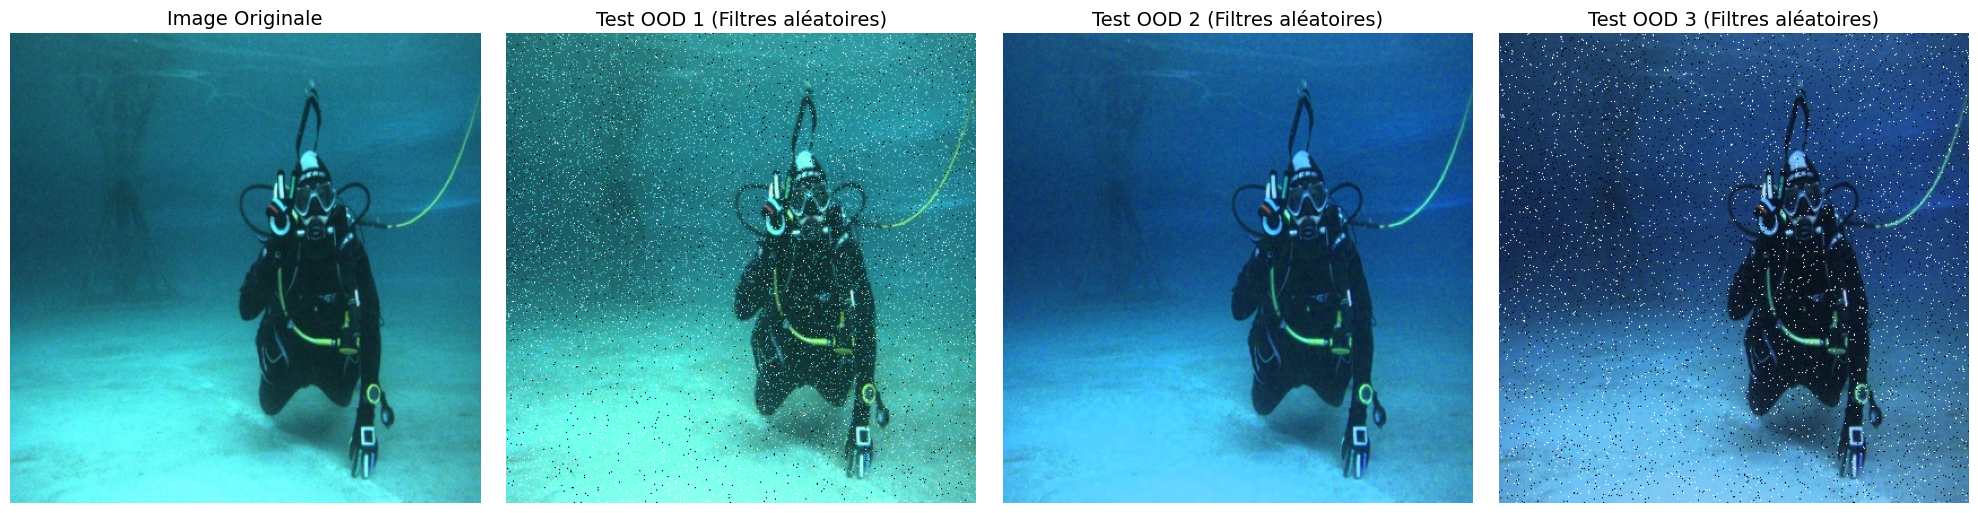

In [ ]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os

# --- 1. DÉFINITION DU PIPELINE OOD (Plus doux et réaliste) ---
test_transform_pipeline = A.Compose([
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.8),

    # Turbidité légère et "neige marine"
    #A.RandomFog(fog_coef_range=(0.05, 0.1), alpha_coef=0.01, p=0.5),

    A.ISONoise(color_shift=(0.1, 0.3), intensity=(0.4, 0.7), p=0.5),

    A.SaltAndPepper(amount_range=(0.01, 0.06), salt_vs_pepper_range=(0.4, 0.6), p=0.5),

], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))


# --- 2. CONFIGURATION DU TEST VISUEL ---
# Prends une image au hasard dans tes dossiers source
img_test_path = '/content/caddy_dataset/dataset_sample_416/POS_brodarski-A_00011_left.jpg'

if not os.path.exists(img_test_path):
    print(f"[ERREUR] L'image {img_test_path} est introuvable.")
    print("Veuillez modifier 'img_test_path' avec le nom exact d'une image de votre dossier.")
else:

    image_test = cv2.cvtColor(cv2.imread(img_test_path), cv2.COLOR_BGR2RGB)
    dummy_bbox = [[0.5, 0.5, 0.2, 0.2]]
    dummy_class = [0]

    # --- 3. AFFICHAGE MULTIPLE ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Affichage de l'originale
    axes[0].imshow(image_test)
    axes[0].set_title("Image Originale", fontsize=14)

    # Génération et affichage de 3 versions augmentées
    for i in range(1, 4):
        try:
            transformed = test_transform_pipeline(
                image=image_test,
                bboxes=dummy_bbox,
                class_labels=dummy_class
            )
            aug_img = transformed['image']

            axes[i].imshow(aug_img)
            axes[i].set_title(f"Test OOD {i} (Filtres aléatoires)", fontsize=14)
        except Exception as e:
            print(f"Erreur lors de l'augmentation {i}: {e}")

    # Masquer les axes pour un rendu plus propre
    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Data Splitting and YOLO Dataset Preparation

This crucial section prepares the final dataset in the format required by YOLO. The complete DataFrame (including true positives and negatives) is divided into training (70%), validation (15%), and testing (15%) sets, using a stratification strategy to maintain class distribution. For each image, a YOLO annotation text file (`.txt`) is created, containing the class ID (0 for 'hand') and the normalized bounding box coordinates. The images and their annotation files are then copied into a specific YOLO folder structure (`images/train`, `labels/train`, etc.).
[albumentation ultralytics](https://docs.ultralytics.com/integrations/albumentations/#how-to-define-custom-transforms)

In [ ]:
import cv2
import os
import pandas as pd
import albumentations as A
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

csv_path = 'caddy_sample_ml_ready.csv'
source_images = '/content/caddy_dataset/dataset_sample_416'
yolo_base_path = '/content/yolo_dataset'

# Préparation des dossiers
folders = ['images/train', 'images/val', 'images/test', 'labels/train', 'labels/val', 'labels/test']
for folder in folders:
    os.makedirs(os.path.join(yolo_base_path, folder), exist_ok=True)

df = pd.read_csv(csv_path)
df['new_filename'] = df['new_filename'].astype(str) # Fix: Ensure new_filename is string type

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label name'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label name'])

# Dictionnaire des classes
caddy_classes = [
    'backwards', 'boat', 'carry', 'down', 'end_comm', 'five',
    'four', 'here', 'mosaic', 'num_delimiter', 'one', 'photo',
    'start_comm', 'three', 'two', 'up'
]
class_to_id = {name: idx for idx, name in enumerate(caddy_classes)}

# Fonction de génération des fichiers (Sans Albumentations)
def process_split_multiclass(dataframe, split_name):
    count = 0
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f"Processing {split_name}"):

        img_name = row['new_filename']
        src_path = os.path.join(source_images, img_name)

        if not os.path.exists(src_path):
            continue

        # Chargement de l'image originale
        image = cv2.imread(src_path)

        bboxes = []
        class_id = -1
        is_positive = img_name.startswith("POS_")
        label_name = row['label name']

        # Si c'est une image positive et que le geste fait partie de nos 16 classes
        if is_positive and label_name != 'background' and row['w_norm'] > 0:
            if label_name in class_to_id:
                class_id = class_to_id[label_name]
                bboxes = [[row['x_center'], row['y_center'], row['w_norm'], row['h_norm']]]

        # Sauvegarde de l'image
        dst_img = os.path.join(yolo_base_path, 'images', split_name, img_name)
        cv2.imwrite(dst_img, image)

        # Sauvegarde du label
        label_file_name = img_name.rsplit('.', 1)[0] + '.txt'
        dst_txt = os.path.join(yolo_base_path, 'labels', split_name, label_file_name)

        with open(dst_txt, 'w') as f:
            # On écrit l'ID spécifique de la classe (0 à 15)
            if len(bboxes) > 0 and class_id != -1:
                x, y, w, h = bboxes[0]
                f.write(f"{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

        count += 1
    return count

# Exécution
print("\nGenerating Multiclass YOLO Dataset...")
train_count = process_split_multiclass(train_df, 'train')
val_count = process_split_multiclass(val_df, 'val')
test_count = process_split_multiclass(test_df, 'test')

print(f"\n--- YOLO Dataset ready --- ")
print(f"Total images generated : {train_count + val_count + test_count} / {len(df)}")


Generating Multiclass YOLO Dataset...


Processing test: 100%|██████████| 1672/1672 [00:03<00:00, 420.80it/s]


--- YOLO Dataset ready --- 
Total images generated : 11144 / 11144


### Visualisation des Effets des Filtres d'Augmentation sur les Images de Test

Cette section permet de vérifier visuellement l'impact des transformations définies dans `test_transform_pipeline` sur les images du jeu de test. Nous sélectionnerons quelques images aléatoires, appliquerons les filtres et afficherons l'image originale et sa version augmentée pour comparaison.

In [ ]:
import matplotlib.pyplot as plt
import random
import cv2
import os
from PIL import Image
import numpy as np

print("--- 👁️ Vérification visuelle des filtres d'augmentation sur les images de test ---")

test_images_path = '/content/yolo_dataset/images/test'

# Get a list of all image files in the test directory
all_test_images = [f for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Select a few random images to display
num_images_to_display = 3 # You can change this number
selected_images = random.sample(all_test_images, min(num_images_to_display, len(all_test_images)))

for img_filename in selected_images:
    image_path = os.path.join(test_images_path, img_filename)

    # Load original image
    original_image_bgr = cv2.imread(image_path)
    original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)

    # Placeholder for bounding boxes and class_id (these are needed for the pipeline, even if empty)
    bboxes = []
    class_labels = []

    # Apply the test transformation pipeline
    # For simplicity, we assume no bboxes for this visualization for now, focusing on image transforms
    try:
        transformed = test_transform_pipeline(image=original_image_rgb, bboxes=bboxes, class_labels=class_labels)
        augmented_image_rgb = transformed['image']
    except Exception as e:
        print(f"Could not apply transformation to {img_filename}: {e}. Displaying original only.")
        augmented_image_rgb = original_image_rgb # Fallback if transformation fails

    # Display original and augmented images
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    fig.suptitle(f"Image: {img_filename}", fontsize=16)

    axes[0].imshow(original_image_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(augmented_image_rgb)
    axes[1].set_title("Augmented Image (Test Filters Applied)")
    axes[1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()


### Verification: Counting Empty Labels (Backgrounds)
This script checks all generated YOLO label files and counts how many are empty. This should match the number of 'background' images (True Negatives) we added.

In [ ]:
import os

def verify_background_labels(base_path):
    splits = ['train', 'val', 'test']
    results = {}

    print("--- 🔍 Verification of Background Labels (Content Check) ---")

    for split in splits:
        label_dir = os.path.join(base_path, 'labels', split)
        if not os.path.exists(label_dir):
            continue

        all_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
        background_files = []

        for f in all_files:
            file_path = os.path.join(label_dir, f)
            with open(file_path, 'r') as file:
                content = file.read()
                # Check if file is empty or contains almost nothing (like a single newline)
                if len(content.strip()) < 3:
                    background_files.append(f)

        results[split] = {
            'total': len(all_files),
            'backgrounds': len(background_files)
        }

        print(f"Split {split.upper()}:")
        print(f"  - Total labels: {len(all_files)}")
        print(f"  - Backgrounds detected: {len(background_files)}")

    total_bg = sum(v['backgrounds'] for v in results.values())
    print(f"\nTotal Background labels found: {total_bg}")

    if total_bg == 1000:
        print("✅ Success! All 1000 background images are correctly identified.")
    else:
        print(f"ℹ️ Note: Found {total_bg} background labels. Expected 1000.")

verify_background_labels('/content/yolo_dataset')

--- 🔍 Verification of Background Labels (Content Check) ---
Split TRAIN:
  - Total labels: 7273
  - Backgrounds detected: 743
Split VAL:
  - Total labels: 1638
  - Backgrounds detected: 162
Split TEST:
  - Total labels: 1635
  - Backgrounds detected: 161

Total Background labels found: 1066
ℹ️ Note: Found 1066 background labels. Expected 1000.


### Label Distribution and Positive/Negative Counts per Split

This script analyzes the final YOLO dataset structure to determine the distribution of original gesture labels and the count of positive (hand detected) and negative (background) samples within the training, validation, and test sets. It relies on the `caddy_sample_ml_ready.csv` to link filenames back to their original `label name`.


In [ ]:
import os
import pandas as pd
from collections import defaultdict

# Path to the processed CSV with original labels and filenames
csv_path = 'caddy_sample_ml_ready.csv'
# Base path to the YOLO dataset images
yolo_images_base_path = '/content/yolo_dataset/images'

print("--- 📊 Analyzing label distribution and positive/negative counts ---")

df_ml_ready = pd.read_csv(csv_path)
filename_to_label = dict(zip(df_ml_ready['new_filename'], df_ml_ready['label name']))

splits = ['train', 'val', 'test']

for split in splits:
    print(f"\n----- Split: {split.upper()} -----")
    split_image_folder = os.path.join(yolo_images_base_path, split)

    if not os.path.exists(split_image_folder):
        print(f"  ⚠️ Image folder for {split} not found at {split_image_folder}")
        continue

    label_counts = defaultdict(int)
    positive_count = 0
    negative_count = 0
    total_images_in_split = 0

    # Iterate through all images in the current split folder
    for img_filename in os.listdir(split_image_folder):
        # Get the original label name using the dictionary
        label = filename_to_label.get(img_filename, 'UNKNOWN_LABEL') # Handle potential missing entries

        label_counts[label] += 1
        total_images_in_split += 1

        if label == 'background':
            negative_count += 1
        else:
            positive_count += 1

    print(f"  Total images: {total_images_in_split}")
    print(f"  Positive samples (hand detected): {positive_count}")
    print(f"  Negative samples (background): {negative_count}")
    print("  Label distribution (original gestures):")
    for label, count in sorted(label_counts.items()):
        print(f"    - {label}: {count}")

print("\n--- 🏆 Analysis Complete ---")

--- 📊 Analyzing label distribution and positive/negative counts ---

----- Split: TRAIN -----
  Total images: 7267
  Positive samples (hand detected): 6567
  Negative samples (background): 700
  Label distribution (original gestures):
    - background: 700
    - backwards: 393
    - boat: 305
    - carry: 502
    - down: 323
    - end_comm: 922
    - five: 34
    - four: 164
    - here: 183
    - mosaic: 212
    - num_delimiter: 694
    - one: 113
    - photo: 647
    - start_comm: 1274
    - three: 272
    - two: 283
    - up: 246

----- Split: VAL -----
  Total images: 1638
  Positive samples (hand detected): 1488
  Negative samples (background): 150
  Label distribution (original gestures):
    - background: 150
    - backwards: 84
    - boat: 98
    - carry: 107
    - down: 70
    - end_comm: 198
    - five: 7
    - four: 36
    - here: 39
    - mosaic: 92
    - num_delimiter: 149
    - one: 24
    - photo: 139
    - start_comm: 273
    - three: 58
    - two: 61
    - up: 53

-----

# Saving Data to Google Drive

This function is designed to save the entire YOLO dataset and the final CSV file to Google Drive. This ensures that work is not lost and can be restored later or shared. The `yolo_dataset` folder is compressed into a `.zip` file which is then copied to Drive. The `caddy_sample_ml_ready.csv` file is also saved.

In [ ]:
drive.mount('/content/drive')

def update_drive():
    print("\n--- 💾 Updating backup on Google Drive ---")

    yolo_folder = '/content/yolo_dataset'
    local_zip_path = '/content/yolo_dataset_backup.zip'
    drive_zip_path = '/content/drive/MyDrive/Internship_Australia/dataset/1model_dataset_clean.zip'
    local_csv_path = '/content/caddy_sample_ml_ready.csv'
    drive_csv_path = '/content/drive/MyDrive/Internship_Australia/dataset/clean_sample_1model.csv'

    if not os.path.exists(yolo_folder):
        print("❌ Error: YOLO folder does not exist.")
        return

    # Create new ZIP
    print("📦 Creating new ZIP archive...")
    os.system(f'zip -r -q {local_zip_path} {yolo_folder}')

    # Overwrite on Drive
    print("🔄 Replacing old files on your Drive...")
    # shutil.copy automatically overwrites the destination file if it already exists
    shutil.copy(local_zip_path, drive_zip_path)

    if os.path.exists(local_csv_path):
        shutil.copy(local_csv_path, drive_csv_path)

    print("✅ Success! Your Drive is up to date with your brand new dataset.")

# Execute backup
update_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- 💾 Updating backup on Google Drive ---
📦 Creating new ZIP archive...
🔄 Replacing old files on your Drive...
✅ Success! Your Drive is up to date with your brand new dataset.


In [ ]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')

# Path configuration
drive_path = '/content/drive/MyDrive/Internship_Australia/dataset/'
local_zip = '/content/yolo_dataset_backup.zip'
local_csv = '/content/caddy_sample_ml_ready.csv'

print("\n--- 🔄 Environment restoration ---")

# Restoration of the YOLO dataset
zip_drive_path = os.path.join(drive_path, '1model_dataset_clean.zip')
if os.path.exists(zip_drive_path):
    print("📦 Restoring the YOLO archive...")
    shutil.copy(zip_drive_path, local_zip)

    print("📂 Unzipping the dataset...")
    # The old folder is deleted, if it exists, to avoid conflicts
    if os.path.exists('/content/yolo_dataset'):
        shutil.rmtree('/content/yolo_dataset')

    os.system(f'unzip -q {local_zip} -d /')
    print("✅ YOLO dataset restored in /content/yolo_dataset")
else:
    print("❌ Error: YOLO archive not found on Drive.")

# Restauration of CSV ML Ready
csv_drive_path = os.path.join(drive_path, 'clean_sample_1model.csv')
if os.path.exists(csv_drive_path):
    shutil.copy(csv_drive_path, local_csv)
    print(f"✅ CSV file '{os.path.basename(local_csv)}' restored.")
else:
    print("⚠️ Please note: CSV file not found on Drive.")

print("\n✨ Restoration complete. Ready for the detection stage !")

Mounted at /content/drive

--- 🔄 Environment restoration ---
📦 Restoring the YOLO archive...
📂 Unzipping the dataset...
✅ YOLO dataset restored in /content/yolo_dataset
✅ CSV file 'caddy_sample_ml_ready.csv' restored.

✨ Restoration complete. Ready for the detection stage !


# Step 2 : Detection

## YOLOv8n Model Installation and Configuration

This section installs the `ultralytics` library (which contains YOLOv8) and configures the `data.yaml` file essential for training. This YAML file tells YOLO where to find the training, validation, and test images, as well as the number of classes (`nc`) and their names (`names`). In this case, we detect a single class: 'hand'.

In [ ]:
!pip install ultralytics albumentations -q

caddy_classes = [
    'backwards', 'boat', 'carry', 'down', 'end_comm', 'five',
    'four', 'here', 'mosaic', 'num_delimiter', 'one', 'photo',
    'start_comm', 'three', 'two', 'up'
]

# Create configuration file
yaml_path = '/content/yolo_dataset/data.yaml'

yaml_data = {
    'path': '/content/yolo_dataset',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(caddy_classes),
    'names': caddy_classes
}

with open(yaml_path, 'w') as f:
    import yaml
    yaml.dump(yaml_data, f, default_flow_style=False, sort_keys=False)

print("\n--- data.yaml created with {len(caddy_classes)} classes! ---")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.2 MB/s eta 0:00:00

--- data.yaml created with {len(caddy_classes)} classes! ---


## Model Training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
drive_path = '/content/drive/MyDrive/YOLO_Training'
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

from ultralytics import YOLO
print("Loading YOLOv8 Nano model...")
model = YOLO('yolov8n.pt')

print("\nStarting training!")
print("The model will learn to detect hands...")

# Start of the learning phase
results = model.train(
    data='/content/yolo_dataset/data.yaml', # The map of our data
    epochs=100,          # Number of times the AI will see the entire dataset
    imgsz=416,          # The size of our images
    batch=16,           # Number of images processed at the same time
    project='/content/drive/MyDrive/YOLO_Training', # The main folder where our results will be saved
    name='Modele_Unique_Final',
    save_period=5,       # Save a full checkpoint every 5 epochs
    # --- DYNAMIC AUGMENTATION PARAMETERS ---
    degrees=20.0,       # Random rotation between -20 and +20 degrees
    translate=0.1,      # Random translation (10% horizontally and vertically)
    scale=0.5,          # Random zoom in/out (+/- 50%)
    fliplr=0.5,         # 50% chance to flip the image left-right (mirror)
    hsv_h=0.015,        # Random hue shift (color tint)
    hsv_s=0.7,          # Random saturation shift (simulates murky water)
    hsv_v=0.4,          # Random brightness shift (simulates depth/darkness)
    mosaic=1.0,         # 100% chance to mix 4 images together (Excellent for robustness)
    erasing=0.2         # 20% chance to randomly hide part of the image (forces the AI to guess)
)

print("\n--- Training complete! ---")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLOv8 Nano model...

Starting training!
The model will learn to detect hands...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=20.0, deterministic=True, device=None, dfl=1.5, dnn

### Saving Training Results to Google Drive

After training the model, it is crucial to save the results and the model itself. This section compresses the training results folder (`runs/detect/Caddy_Projet/Premier_Test`) and copies it to Google Drive. The best-trained model (`best.pt`) is also copied directly to the root of the Drive for easy access. This ensures the persistence of your work.

In [ ]:
print("Checking Drive connection...")
drive.mount('/content/drive')

print("\nSaving training results...")
results_folder = '/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final'
results_zip_path = '/content/yolo_resultats_backup.zip'
drive_folder = '/content/drive/MyDrive/Internship_Australia/unique_model/'

if os.path.exists(results_folder):
    print("📦 Creating results archive...")
    os.system(f'zip -r -q {results_zip_path} {results_folder}')
    shutil.copy(results_zip_path, os.path.join(drive_folder, 'yolo_resultats_backup.zip'))
    print("✅ The complete results folder is saved!")

    local_model_path = os.path.join(results_folder, 'weights/best.pt')
    if os.path.exists(local_model_path):
        shutil.copy(local_model_path, os.path.join(drive_folder, '1model_best.pt'))
        print("✅ Your AI model (best.pt) has been copied to the root of your Drive for easy access!")
else:
    print("❌ Error: Results folder not found.")

print("\n--- Everything is safe! ---")

Checking Drive connection...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Saving training results...
📦 Creating results archive...
✅ The complete results folder is saved!
✅ Your AI model (best.pt) has been copied to the root of your Drive for easy access!

--- Everything is safe! ---


## Restoring the session from Drive

In [ ]:
# Drive connection
drive.mount('/content/drive')

# Path configuration
drive_folder = '/content/drive/MyDrive/Internship_Australia/Test2/'
files_to_retrieve = {
    'dataset': 'yolo_dataset_backup_test2.zip',
    'csv': 'caddy_sample_ml_ready_test2.csv',
    'modele': 'yolo_main_best_test2.pt',
    'results': 'yolo_results_backup_test2.zip'
}

print("\n--- 🔄 Restoring working environment ---")

# Dataset retrieval and decompression
zip_path = os.path.join(drive_folder, files_to_retrieve['dataset'])
if os.path.exists(zip_path):
    if not os.path.exists('/content/yolo_dataset'):
        print(f"📦 Decompressing dataset ({files_to_retrieve['dataset']})...")
        os.system(f'unzip -q {zip_path} -d /')
        print("   ✅ Dataset restored in /content/yolo_dataset")
    else:
        print("   ℹ️ Dataset already present locally.")
else:
    print(f"   ❌ Archive {files_to_retrieve['dataset']} not found on Drive.")

# CSV file retrieval
csv_path = os.path.join(drive_folder, files_to_retrieve['csv'])
if os.path.exists(csv_path):
    shutil.copy(csv_path, '/content/caddy_sample_ml_ready.csv')
    print(f"   ✅ CSV '{files_to_retrieve['csv']}' restored.")
else:
    print(f"   ❌ CSV not found on Drive.")

# Trained Model Retrieval (The "Brain")
model_path = os.path.join(drive_folder, files_to_retrieve['modele'])
if os.path.exists(model_path):
    # Keep it on Drive for direct reading, or copy it locally
    shutil.copy(model_path, '/content/yolo_main_best.pt')
    print(f"   ✅ Model '{files_to_retrieve['modele']}' restored locally.")
else:
    print(f"   ⚠️ No trained model found. (Normal if you haven't finished training yet).")

# Results
results_path = os.path.join(drive_folder, files_to_retrieve['results'])
if os.path.exists(results_path):
    if not os.path.exists('/content/yolo_results'):
        print(f"📦 Decompressing dataset ({files_to_retrieve['results']})...")
        os.system(f'unzip -q {results_path} -d /')
        print("   ✅ Dataset restored in /content/yolo_results")
    else:
        print("   ℹ️ Dataset already present locally.")
else:
    print(f"   ❌ Archive {files_to_retrieve['results']} not found on Drive.")

# Install software dependencies
print("\n--- 🛠️ Installing libraries ---")
!pip install ultralytics -q
from ultralytics import YOLO
print("✅ Environment ready to use!")

Mounted at /content/drive

--- 🔄 Restoring working environment ---
   ❌ Archive yolo_dataset_backup_test2.zip not found on Drive.
   ❌ CSV not found on Drive.
   ⚠️ No trained model found. (Normal if you haven't finished training yet).
   ❌ Archive yolo_results_backup_test2.zip not found on Drive.

--- 🛠️ Installing libraries ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Environment ready to use!


### Training Resume Options

This section presents different ways to manage model training: restarting from scratch, resuming from a saved checkpoint, or adapting it for new data.

### New training: 3 possible scenarios:
- [Restart training from scratch](https://colab.research.google.com/drive/1WDkPkDyT3iV8D64QBaUA04aw8Gxoc_U1#scrollTo=pQVQ9NELoc3h&line=1&uniqifier=1)
- [Resume training](https://colab.research.google.com/drive/1WDkPkDyT3iV8D64QBaUA04aw8Gxoc_U1#scrollTo=grYMpvebnkgg&line=1&uniqifier=1): Recover 20 epochs and continue with the same configuration
- Add new data:

### Resume training

In [ ]:
!pip install ultralytics albumentations -q
from ultralytics import YOLO
# Load the LAST checkpoint (not the best, but the latest state)
model = YOLO('/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final-2/weights/last.pt')

# Restart training with resume=True
# Ensure the correct data.yaml is passed to match the original training configuration
model.train(
    data='/content/yolo_dataset/data.yaml',
    device=0,
    resume=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=20.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac78b2cb5f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

## Detection Demonstration with the Trained Model

This section loads the trained YOLOv8 model (`yolo_main_best.pt`) and uses it to perform a prediction on a specific test image. The original image is displayed next to the image with bounding boxes and detection labels overlaid by the AI. This allows for direct visualization of the model's performance in action.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- Multiclass Gesture Detection Demonstration ---
✅ Model loaded successfully!

🔍 Analyzing image 'POS_biograd-A_00007_left.jpg'...

image 1/1 /content/yolo_dataset/images/train/POS_biograd-A_00007_left.jpg: 416x416 1 five, 6.0ms
Speed: 6.3ms preprocess, 6.0ms inference, 35.3ms postprocess per image at shape (1, 3, 416, 416)


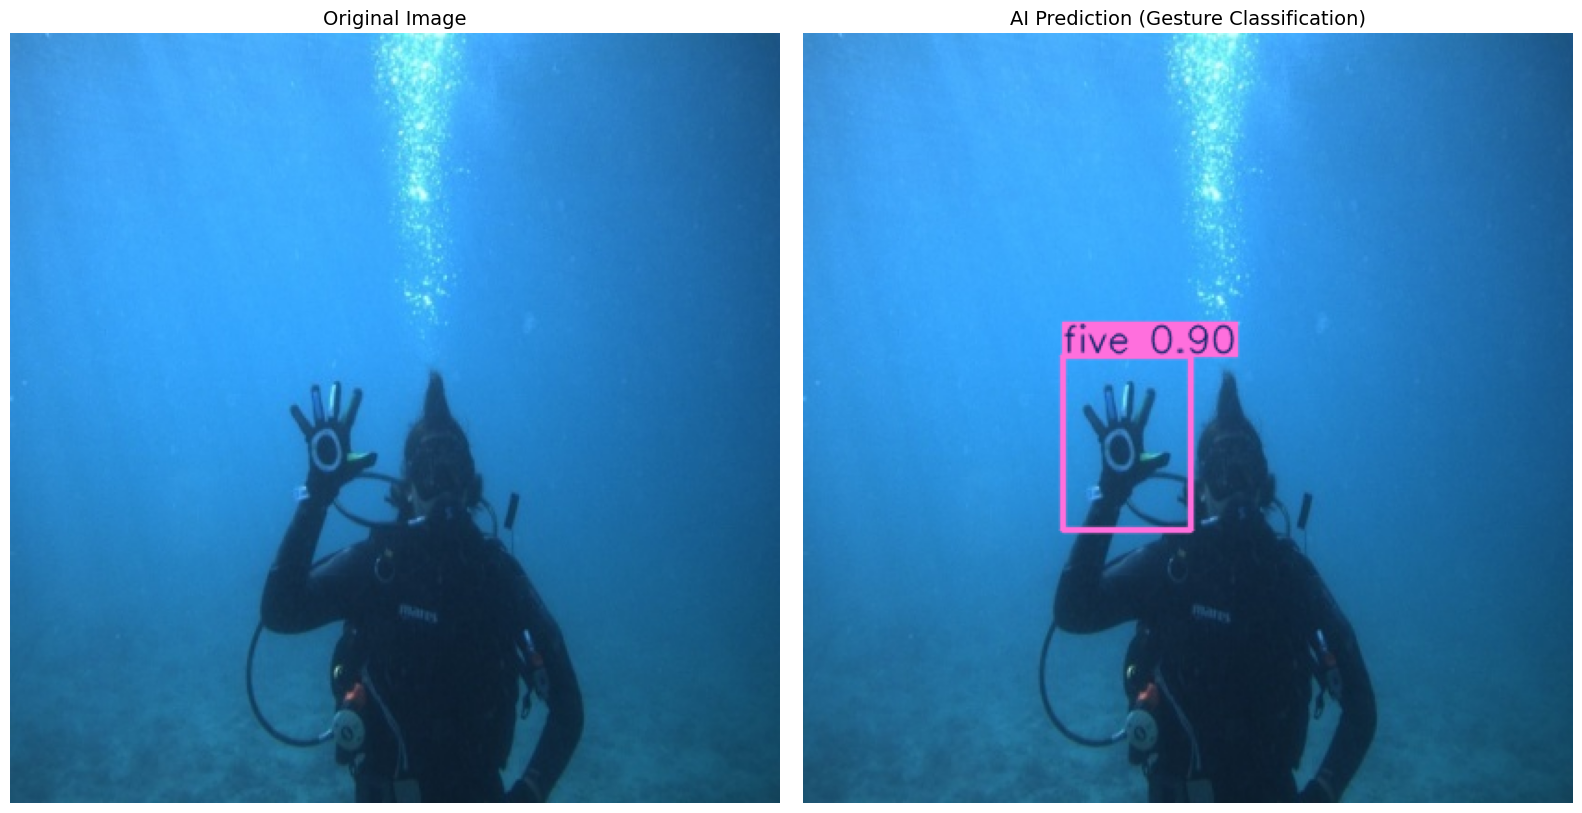

In [ ]:
import random
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import os

print("--- Multiclass Gesture Detection Demonstration ---")

# Path to the best model weights from the last training run
model_path = '/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final-2/weights/best.pt'

if not os.path.exists(model_path):
    print(f"❌ Model not found at {model_path}. Please check the path.")
else:
    model = YOLO(model_path)
    print("✅ Model loaded successfully!\n")

    # --- MODIFIED: Directly specify the image path ---
    # Replace 'your_image.jpg' with the actual path to the image you want to test
    image_demo_path = '/content/yolo_dataset/images/train/POS_biograd-A_00007_left.jpg' # Example path

    if not os.path.exists(image_demo_path):
        print(f"❌ Error: The image '{image_demo_path}' was not found. Please provide a valid path.")
    else:
        # AI Prediction
        print(f"🔍 Analyzing image '{os.path.basename(image_demo_path)}'...")
        results = model(image_demo_path)

        # Image Display
        original_img = Image.open(image_demo_path)
        yolo_img = results[0].plot() # This includes the bounding box and label
        yolo_img_rgb = cv2.cvtColor(yolo_img, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        axes[0].imshow(original_img)
        axes[0].set_title("Original Image", fontsize=14)
        axes[0].axis('off')

        axes[1].imshow(yolo_img_rgb)
        axes[1].set_title("AI Prediction (Gesture Classification)", fontsize=14)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

### Final Model Evaluation on the Augmented Test Set

This step evaluates the performance of the trained model on the test set. It is important to note that this test set includes augmented images (with different types of noise and rotations), providing a more robust measure of the model's generalization ability. The `mAP50` metric (mean Average Precision at an IoU threshold of 0.50) is used as the primary performance indicator. The path to the `data.yaml` file is used to specify the dataset configuration, and the evaluation is run on `split='test'`.

In [ ]:
from ultralytics import YOLO

print("--- 📝 Final Exam: Evaluation on the Test Set ---")

# Loading the best-trained model
model_path = '/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final-2/weights/best.pt'
model = YOLO(model_path)

# Launch evaluation exclusively on the 'test' folder
yaml_path = '/content/yolo_dataset/data.yaml'
metrics = model.val(data=yaml_path, split='test')

# Display final result
print("\n--- 🏆 TEST RESULT ---")
print(f"mAP50 on unseen and noisy data: {metrics.box.map50:.3f}")

--- 📝 Final Exam: Evaluation on the Test Set ---
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1664.4±457.4 MB/s, size: 38.0 KB)
val: Scanning /content/yolo_dataset/labels/test... 1635 images, 161 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1635/1635 2.6Kit/s 0.6s
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 9.7it/s 10.6s
                   all       1635       1474      0.981      0.981      0.989      0.705
             backwards         84         84          1      0.994      0.995      0.689
                  boat        100        100      0.965          1      0.994      0.745
                 carry        107        107      0.997          1      0.995      0.727
                  do

--- Starting Overfitting Evaluation on Test Set ---
Evaluating Epoch 0...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1714.5±630.0 MB/s, size: 38.0 KB)
val: Scanning /content/yolo_dataset/labels/test.cache... 1635 images, 161 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1635/1635 527.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 9.0it/s 11.4s
                   all       1635       1474       0.58      0.438      0.454      0.214
Speed: 0.6ms preprocess, 1.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-3
Evaluating Epoch 5...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fa

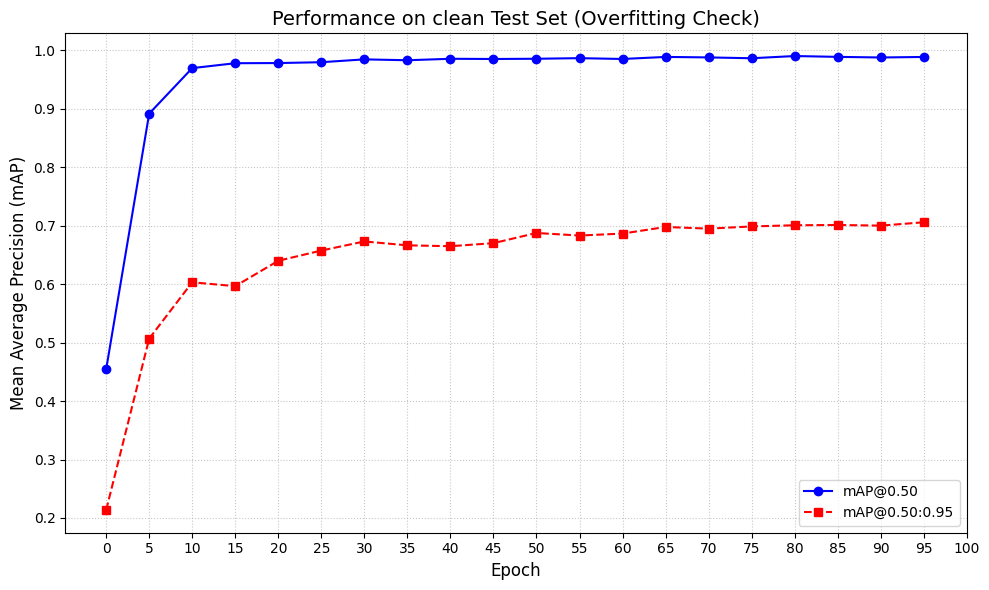

In [ ]:
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Configuration
weights_dir = '/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final-2/weights'
yaml_path = '/content/yolo_dataset/data.yaml'

epochs = []
map50_scores = []
map50_95_scores = []

print("--- Starting Overfitting Evaluation on Test Set ---")

# Iterate through the saved checkpoints (from 5 to 100, step 5)
for epoch in range(0, 102, 5):
    ckpt_path = os.path.join(weights_dir, f'epoch{epoch}.pt')

    # Check if the checkpoint exists (in case training stopped early)
    if os.path.exists(ckpt_path):
        print(f"Evaluating Epoch {epoch}...")

        # Load the specific checkpoint
        model = YOLO(ckpt_path)

        # Run validation explicitly on the 'test' split
        # verbose=False keeps the console clean
        metrics = model.val(data=yaml_path, split='test', verbose=False)

        # Store metrics
        epochs.append(epoch)
        map50_scores.append(metrics.box.map50)
        map50_95_scores.append(metrics.box.map)
    else:
        print(f"Checkpoint for epoch {epoch} not found. Stopping evaluation.")
        break

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot mAP@50
plt.plot(epochs, map50_scores, marker='o', linestyle='-', color='b', label='mAP@0.50')
# Plot mAP@50-95 (Stricter metric)
plt.plot(epochs, map50_95_scores, marker='s', linestyle='--', color='r', label='mAP@0.50:0.95')

plt.title('Performance on clean Test Set (Overfitting Check)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Average Precision (mAP)', fontsize=12)
plt.xticks(range(0, 101, 5))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()

# Save the plot for the tutor
plot_path = '/content/overfitting_curve.png'
plt.savefig(plot_path)
print(f"\nCurve saved to {plot_path}")

plt.show()

# export the model

In [ ]:
!pip install ultralytics albumentations -q
from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final-2/weights/best.pt')
model.export(format='onnx')
model.export(format='ncnn')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final-2/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 20, 3549) (5.9 MB)
requirements: Ultralytics requirements ['

'/content/drive/MyDrive/YOLO_Training/Modele_Unique_Final-2/weights/best_ncnn_model'

In [ ]:
import os
from ultralytics import YOLO

yaml_path = '/content/yolo_dataset/data.yaml'

formats_a_tester = [
    {"nom": "PyTorch", "chemin": "/content/drive/MyDrive/control_vision_project/best_modele_unique.pt"},
    {"nom": "ONNX", "chemin": "/content/drive/MyDrive/control_vision_project/best_modele_unique.onnx"},
    {"nom": "NCNN", "chemin": "/content/drive/MyDrive/control_vision_project/best_modele_unique_ncnn_model"}
]

print("=== GÉNÉRATION DES MATRICES DE CONFUSION ===")

for modele_info in formats_a_tester:
    nom = modele_info["nom"]
    chemin = modele_info["chemin"]

    if os.path.exists(chemin):
        print(f"\n Évaluation du format : {nom}...")

        model = YOLO(chemin, task='detect')
        metrics = model.val(
            data=yaml_path,
            split='test',
            name=f'eval_format_{nom}',
            verbose=False,
            imgsz=416
        )
        print(f"[SUCCÈS] Résultats sauvegardés pour {nom}.")
    else:
        print(f"[ATTENTION] Le modèle {chemin} est introuvable. Évaluation ignorée.")

=== GÉNÉRATION DES MATRICES DE CONFUSION ===

[INFO] Évaluation du format : PyTorch...
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1871.7±589.3 MB/s, size: 36.3 KB)
val: Scanning /content/yolo_dataset/labels/test.cache... 1635 images, 161 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1635/1635 428.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 10.3it/s 10.0s
                   all       1635       1474      0.981      0.981      0.989      0.705
Speed: 0.6ms preprocess, 1.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/eval_format_PyTorch-2
[SUCCÈS] Résultats sauvegardés pour PyTorch.

[INFO] Évaluation du format : ONNX...
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913